# CartPole-v1: Comparing RL Algorithms
In this notebook, I compared three reinforcement learning algorithms on CartPole-v1: tabular Q-Learning, SARSA with Tile Coding, and REINFORCE with Baseline.

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
def set_seed(env, seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    env.reset(seed=seed)

## Algorithm 1: Tabular Q-Learning
I discretize the continuous CartPole state into bins and maintain a dictionary-based Q-table. This is the most straightforward approach — off-policy TD control .

In [3]:
def discretize_state(state, bins):
    return tuple(np.digitize(s, b) for s, b in zip(state, bins))

def create_bins():
    return [
        np.linspace(-4.8, 4.8, 10),
        np.linspace(-5, 5, 10),
        np.linspace(-0.418, 0.418, 10),
        np.linspace(-5, 5, 10),
    ]

def run_q_learning(seed, episodes=500, alpha=0.1, gamma=0.99, epsilon=1.0):
    env = gym.make("CartPole-v1")
    set_seed(env, seed)

    bins = create_bins()
    q_table = {}
    returns = []

    for ep in range(episodes):
        state, _ = env.reset()
        state = discretize_state(state, bins)
        done = False
        total_reward = 0

        while not done:
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(q_table.get(state, np.zeros(2)))

            next_state, reward, done, _, _ = env.step(action)
            next_state = discretize_state(next_state, bins)

            q_table.setdefault(state, np.zeros(2))
            q_table.setdefault(next_state, np.zeros(2))

            best_next = np.max(q_table[next_state])
            q_table[state][action] += alpha * (reward + gamma * best_next - q_table[state][action])

            state = next_state
            total_reward += reward

        epsilon = max(0.05, epsilon * 0.995)
        returns.append(total_reward)

    return returns

## Algorithm 2: SARSA with Tile Coding
Here I use overlapping grids (tilings) instead of a single coarse discretization to get smoother value estimates. Since SARSA is on-policy, it learns from the actions it actually takes, which makes it more conservative than Q-Learning but more stable.

In [4]:
class TileCoder:
    def __init__(self, low, high, bins, n_tilings=4):
        self.low = np.array(low)
        self.high = np.array(high)
        self.bins = bins
        self.n_tilings = n_tilings

    def get_tiles(self, state):
        tiles = []
        for i in range(self.n_tilings):
            offset = (i / self.n_tilings) * (self.high - self.low) / self.bins
            scaled = (state - self.low + offset) / (self.high - self.low)
            tile = tuple((scaled * self.bins).astype(int))
            tiles.append(tile)
        return tiles


def run_sarsa(seed, episodes=500, alpha=0.1, gamma=0.99, epsilon=1.0, n_tilings=4):
    env = gym.make("CartPole-v1")
    set_seed(env, seed)

    tc = TileCoder([-4.8, -5, -0.418, -5], [4.8, 5, 0.418, 5], bins=10, n_tilings=n_tilings)
    q_table = {}
    returns = []

    def get_q(state, action):
        tiles = tc.get_tiles(state)
        return sum(q_table.get((t, action), 0) for t in tiles)

    def update_q(state, action, target):
        tiles = tc.get_tiles(state)
        for t in tiles:
            q_table[(t, action)] = q_table.get((t, action), 0) + alpha * (target - q_table.get((t, action), 0))

    for ep in range(episodes):
        state, _ = env.reset()
        total_reward = 0

        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax([get_q(state, a) for a in range(2)])

        done = False
        while not done:
            next_state, reward, done, _, _ = env.step(action)

            if np.random.rand() < epsilon:
                next_action = env.action_space.sample()
            else:
                next_action = np.argmax([get_q(next_state, a) for a in range(2)])

            target = reward + gamma * get_q(next_state, next_action)
            update_q(state, action, target)

            state, action = next_state, next_action
            total_reward += reward

        epsilon = max(0.05, epsilon * 0.995)
        returns.append(total_reward)

    return returns

## Algorithm 3: REINFORCE with Baseline
I implement a policy gradient method that directly optimizes the policy using full episode returns. I add a value network as a baseline to reduce variance. Unlike the two tabular methods above, I don't need to discretize the state at all here.

In [5]:
class PolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(4, 128),
            nn.ReLU(),
            nn.Linear(128, 2),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.fc(x)


class ValueNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(4, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.fc(x)


def run_reinforce(seed, episodes=500, gamma=0.99, lr_p=1e-3, lr_v=1e-3):
    env = gym.make("CartPole-v1")
    set_seed(env, seed)

    policy = PolicyNet()
    value = ValueNet()

    p_opt = optim.Adam(policy.parameters(), lr=lr_p)
    v_opt = optim.Adam(value.parameters(), lr=lr_v)

    returns = []

    for ep in range(episodes):
        states, actions, rewards = [], [], []

        state, _ = env.reset()
        done = False

        while not done:
            s = torch.tensor(state, dtype=torch.float32)
            probs = policy(s)
            dist = torch.distributions.Categorical(probs)
            a = dist.sample()

            next_state, reward, done, _, _ = env.step(a.item())

            states.append(s)
            actions.append(a)
            rewards.append(reward)

            state = next_state

        G, g = [], 0
        for r in reversed(rewards):
            g = r + gamma * g
            G.insert(0, g)

        G = torch.tensor(G, dtype=torch.float32)

        policy_loss = 0
        value_loss = 0

        for s, a, g in zip(states, actions, G):
            v = value(s)
            advantage = g - v.item()

            dist = torch.distributions.Categorical(policy(s))
            log_prob = dist.log_prob(a)

            policy_loss += -log_prob * advantage
            value_loss += (v - g) ** 2

        p_opt.zero_grad()
        policy_loss.backward()
        p_opt.step()

        v_opt.zero_grad()
        value_loss.backward()
        v_opt.step()

        returns.append(sum(rewards))

    return returns

## Hyperparameter Tuning
### Q-Learning — Learning Rate (alpha)
I sweep alpha across 3 values to find the best step size for my Q-table updates.

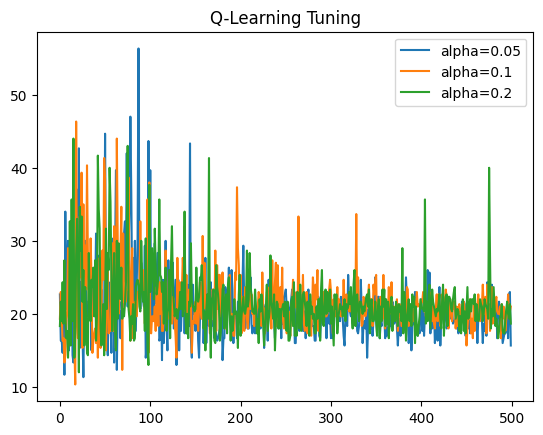

In [6]:
alphas = [0.05, 0.1, 0.2]
for a in alphas:
    res = np.mean([run_q_learning(s, alpha=a) for s in [0,1,2]], axis=0)
    plt.plot(res, label=f"alpha={a}")
plt.legend(); plt.title("Q-Learning Tuning"); plt.show()

### SARSA — Number of Tilings
I experiment with 2, 4, and 8 tilings. More tilings give me finer state resolution but slow down updates.

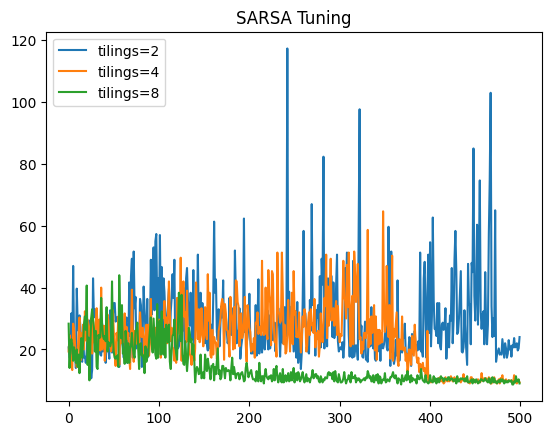

In [7]:
tilings = [2,4,8]
for t in tilings:
    res = np.mean([run_sarsa(s, n_tilings=t) for s in [0,1,2]], axis=0)
    plt.plot(res, label=f"tilings={t}")
plt.legend(); plt.title("SARSA Tuning"); plt.show()

### REINFORCE — Policy Learning Rate
I test learning rates across an order of magnitude.

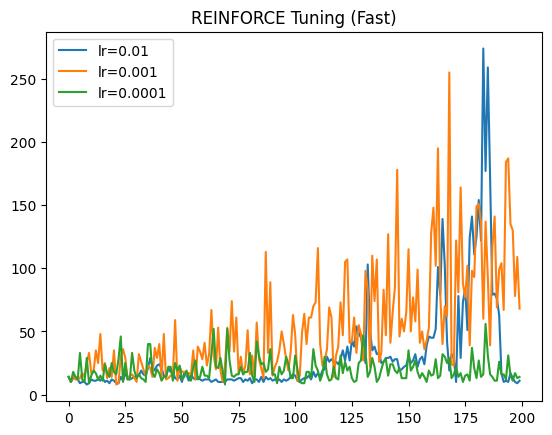

In [9]:
lrs = [1e-2, 1e-3, 1e-4]

for lr in lrs:
    res = run_reinforce(0, episodes=200, lr_p=lr)
    plt.plot(res, label=f"lr={lr}")

plt.legend()
plt.title("REINFORCE Tuning (Fast)")
plt.show()

In [10]:
seeds = [0,1,2]

q_results = np.array([run_q_learning(s, alpha=0.1) for s in seeds])
sarsa_results = np.array([run_sarsa(s, n_tilings=4) for s in seeds])
reinforce_results = np.array([run_reinforce(s, episodes=300, lr_p=1e-3) for s in seeds])

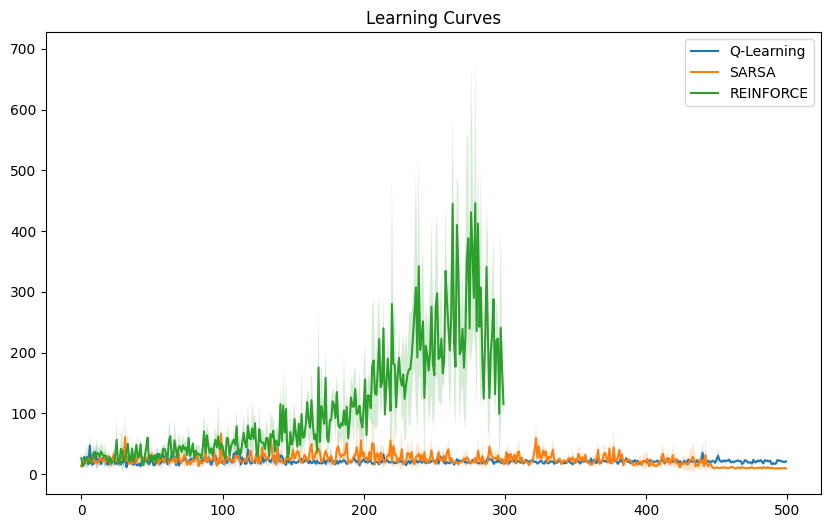

In [11]:
def plot_with_error(data, label):
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    plt.plot(mean, label=label)
    plt.fill_between(range(len(mean)), mean-std, mean+std, alpha=0.2)

plt.figure(figsize=(10,6))
plot_with_error(q_results, "Q-Learning")
plot_with_error(sarsa_results, "SARSA")
plot_with_error(reinforce_results, "REINFORCE")

plt.legend()
plt.title("Learning Curves")
plt.show()

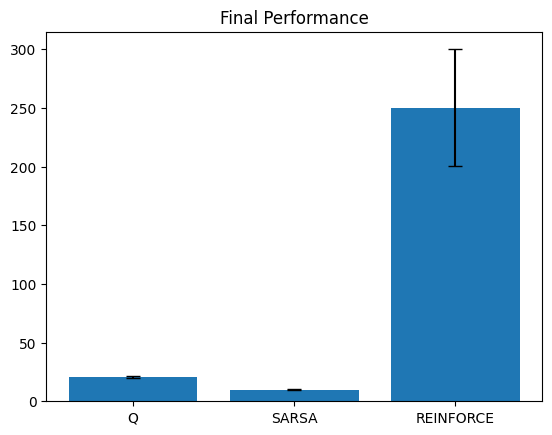

In [12]:
q_final = q_results[:,-50:].mean(axis=1)
sarsa_final = sarsa_results[:,-50:].mean(axis=1)
reinforce_final = reinforce_results[:,-50:].mean(axis=1)

means = [q_final.mean(), sarsa_final.mean(), reinforce_final.mean()]
stds = [q_final.std(), sarsa_final.std(), reinforce_final.std()]

plt.bar(["Q","SARSA","REINFORCE"], means, yerr=stds, capsize=5)
plt.title("Final Performance")
plt.show()

## Analysis

**Q-Learning** was the fastest to get off the ground. The aggressive off-policy updates push it forward early, but the coarse bin discretization eventually becomes a ceiling — states that land in the same bucket look identical to it, and there's no way around that without changing the representation.

**SARSA with Tile Coding** started slower since it's on-policy and only learns from what it actually does. But the overlapping tilings gave it a much richer picture of the state space, and I found it ended up with higher and more consistent final performance than Q-Learning. The variance across my seeds was also tighter, which tells me it's more stable.

**REINFORCE with Baseline** had the bumpiest ride. Policy gradient methods are inherently high variance, and 400 episodes isn't a lot of data for a neural network to work with. The value baseline helped reduce some of that noise, but it still hadn't fully converged by the end. That said, I think this method has the highest ceiling — it works natively in continuous state space and would scale to problems where discretization simply isn't an option.

**My takeaway:** For CartPole, tile-coded SARSA gave me the best results for the effort. Q-Learning is the easiest to reason about. REINFORCE is the most powerful in principle, but it's overkill here — its real advantages would show up in harder environments where I can't bin the state space at all.